In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('hotel_bookings.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
df.loc[df.duplicated()==True]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [4]:
df = df.drop_duplicates()

In [5]:
pd.set_option('display.max_columns', None)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df['days_stayed']= df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df = df.drop(columns=['stays_in_weekend_nights','stays_in_week_nights'])

In [7]:
df['children'] = df['children'].fillna(0)

In [8]:
df['guests'] = df['adults'] + df['children'] + df['babies']
df = df.drop(columns=['adults','children','babies'])

In [9]:
df = df.astype({'guests':'int'})

In [10]:
df = df.drop(columns=['arrival_date_week_number','arrival_date_day_of_month','previous_cancellations','previous_bookings_not_canceled',
                 'reserved_room_type','assigned_room_type','booking_changes','agent','company','days_in_waiting_list',
                 'required_car_parking_spaces','reservation_status','reservation_status_date'])

In [11]:
df['country'] = df['country'].fillna('Unknown')

In [12]:
df = df.rename(columns={'adr':'average_daily_rate'} )

1. Compare the number of bookings across different hotel types

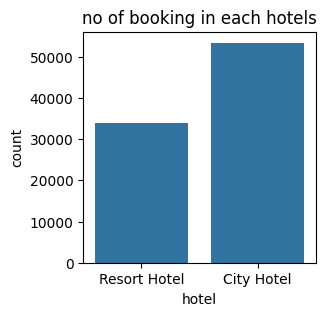

In [13]:
plt.figure(figsize=(3,3))
sns.countplot(df, x='hotel')
plt.title('no of booking in each hotels')
plt.show()

most bookings are in city hotels, 50% more than resort hotels

2. Analyze the ADR (Average Daily Rate) for each hotel type.

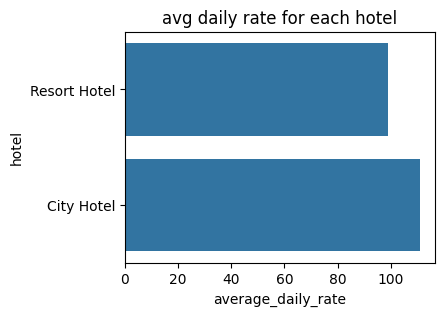

In [14]:
plt.figure(figsize=(4,3))
sns.barplot(df, x='average_daily_rate', y='hotel', errorbar=None)
plt.title('avg daily rate for each hotel')
plt.show()

the adr of city hotel is greater than the resort hotel

3. Plot the distribution of lead time to understand how far in advance people book.

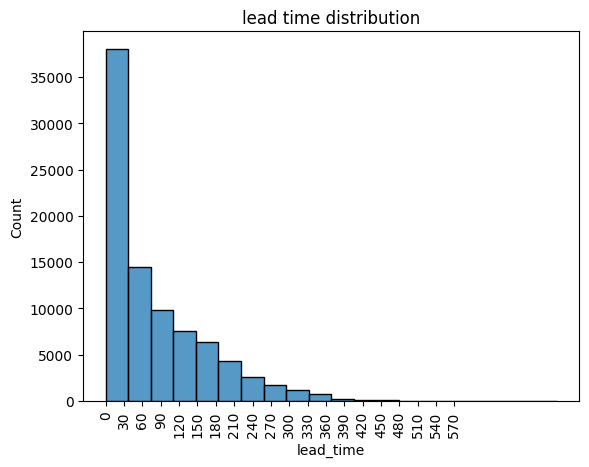

In [15]:
sns.histplot(df, x='lead_time', bins=20)
plt.xticks(range(0, 600, 30), rotation=90)
plt.title('lead time distribution')
plt.show()

most bookings have a very short lead time, with fewer and fewer bookings being made further in advance.

4. Display proportion of bookings by customer type.

In [16]:
cust_cnt = df['customer_type'].value_counts()

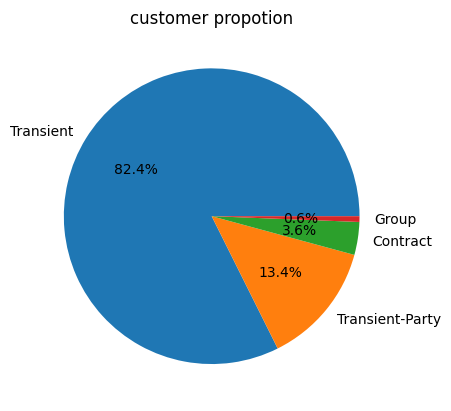

In [17]:
plt.pie(x=cust_cnt.values, labels=cust_cnt.index, autopct='%.1f%%')
plt.title('customer propotion')
plt.show()

more than 90% od booking is from transient & transient-party customer type

5. Explore the relationship between ADR and lead time.

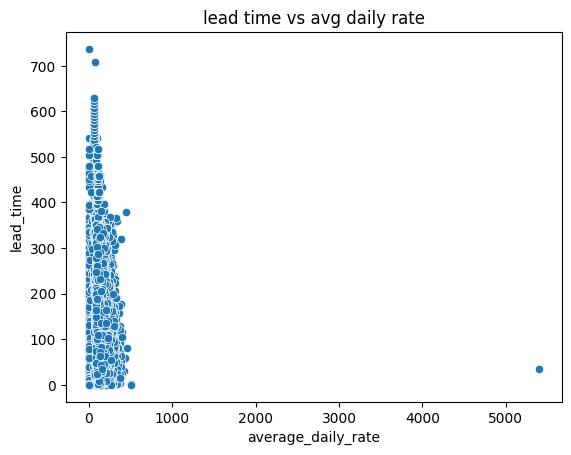

In [18]:
sns.scatterplot(df, x='average_daily_rate', y='lead_time')
plt.title('lead time vs avg daily rate')
plt.show()

lead time mostly in the low region but it extends all the way upto 700, there is no direct relation with ADR here, however there are some extreme outliers in the ADR which is mostly below 500

6. Compare booking cancellations across deposit types (hue = hotel).

In [19]:
cancelled_df = df.loc[df['is_canceled'] == 1]

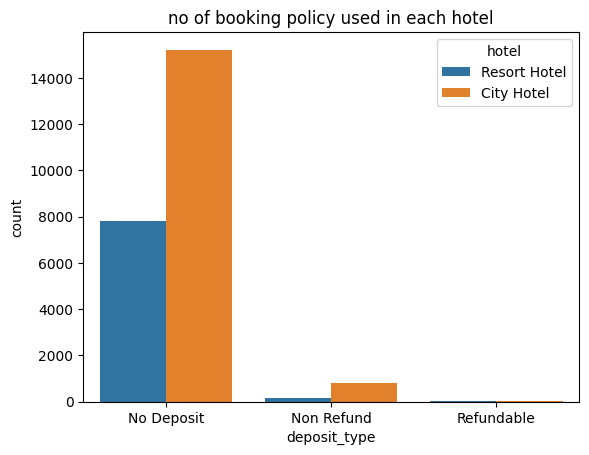

In [20]:
sns.countplot(cancelled_df, x='deposit_type', hue='hotel')
plt.title('no of booking policy used in each hotel')
plt.show()

most bookings are cancelled in the no deposit booking this could be due to the hig volume of booking in this deposit type, both non-refund and refundable is negligible compared to this

most cancellation occurs in city hotel over 14k

7. Compare average special requests between repeated and new guests.

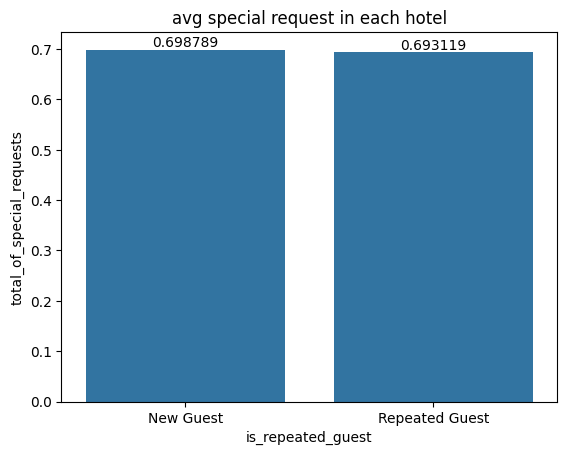

In [21]:
c = sns.barplot(df, y='total_of_special_requests', x='is_repeated_guest', errorbar=None)
plt.xticks([0,1], ['New Guest', 'Repeated Guest'])
plt.bar_label(c.containers[0])
plt.title('avg special request in each hotel')
plt.show()

special request made by new guest and repeated guest is almost similar, a minor edge is for new guests, indicating trust towards the hotel service by repeated guest

8. Show ADR trend across months to identify seasonal price patterns.

In [22]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

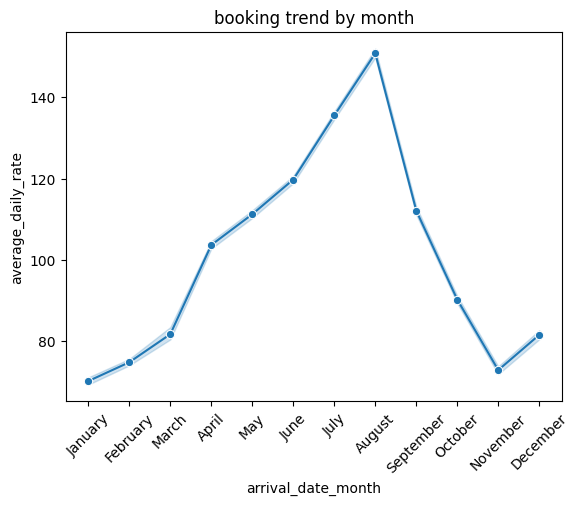

In [23]:
sns.lineplot(df, x='arrival_date_month', y='average_daily_rate', marker='o')
plt.xticks(rotation=45)
plt.title('booking trend by month')
plt.show()

ADR is above 140 during the month of august, and right after auguts showing a significant dip in the ADR in the winter time of nov-feb, this indicates a seasonal shift in pricing

9. Correlation between ADR, lead time, guests, and special requests

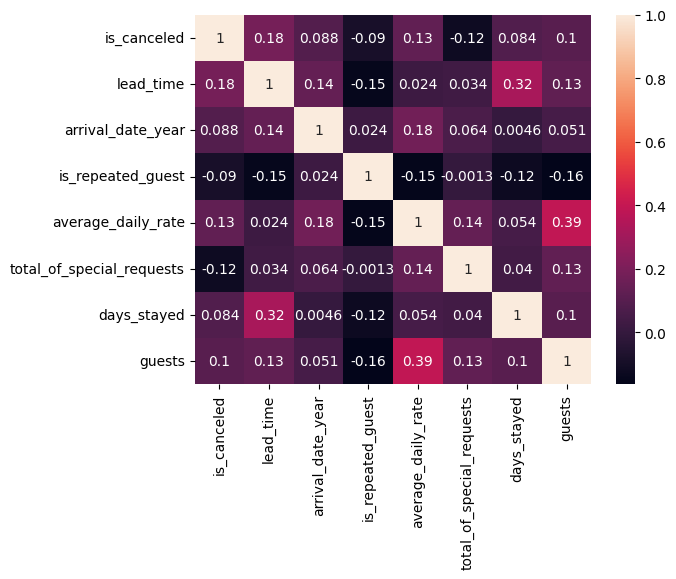

In [24]:
cr = df.corr(numeric_only=True)
sns.heatmap(cr, annot=True)
plt.show()

ADR will increase as the no of guests increase, this is a moderate relation

10. Plot monthly average ADR and average lead time side by side

C:\Users\sayan\AppData\Local\Temp\ipykernel_15516\3808411222.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_order, rotation=45)
C:\Users\sayan\AppData\Local\Temp\ipykernel_15516\3808411222.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_order, rotation=45)


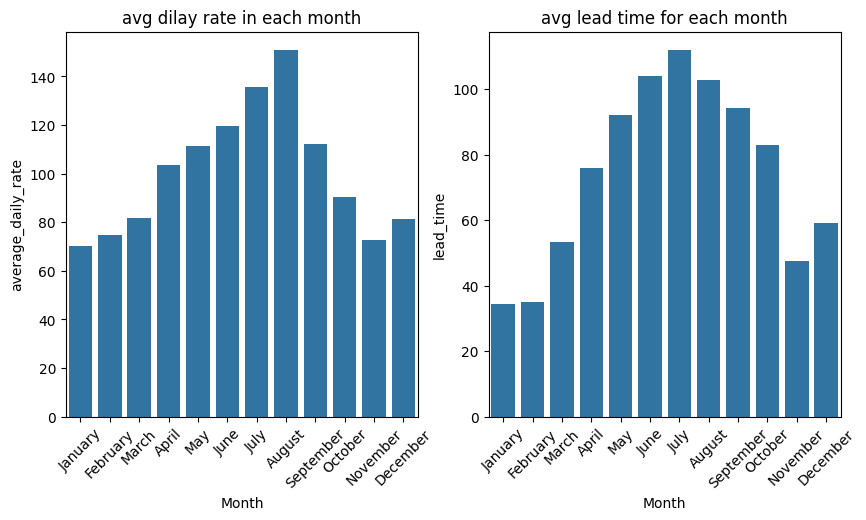

In [25]:
f, a= plt.subplots(ncols=2, figsize=(10,5))
sns.barplot(df, x='arrival_date_month', y='average_daily_rate', order=month_order, errorbar=None, ax=a[0])
sns.barplot(df, x='arrival_date_month', y='lead_time', order=month_order, errorbar=None, ax=a[1])
for ax in a:
    ax.set_xticklabels(month_order, rotation=45)
    ax.set_xlabel("Month")
a[1].set_title('avg lead time for each month')
a[0].set_title('avg dilay rate in each month')
plt.show()

for ADR we can see that during winter the prcie is less and peak to the august

for leadtime it shows the same trend, less lead time during the winter but peaks during june-august showing a direct relationship

11. Compare average ADR by deposit type across both hotels.

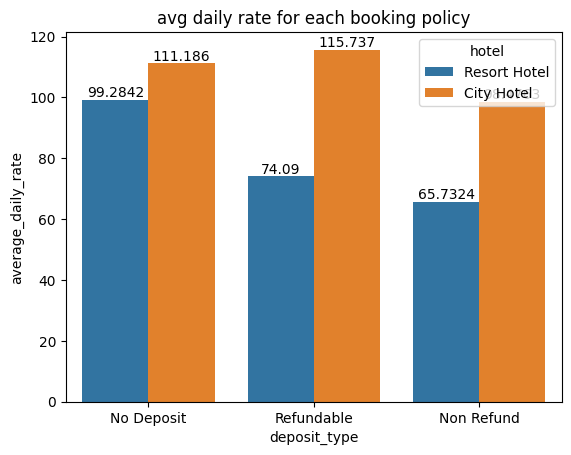

In [26]:
c = sns.barplot(df, x='deposit_type', y='average_daily_rate', hue='hotel', errorbar=None)
for c in c.containers:
    plt.bar_label(c)
plt.title('avg daily rate for each booking policy')
plt.show()

The highest average ADR is found in City Hotels with a Refundable deposit

The lowest average ADR is found in Resort Hotels with a Non Refund deposit

both hotels, the No Deposit ADR is consistently high

12. Analyze number of special requests by customer type.

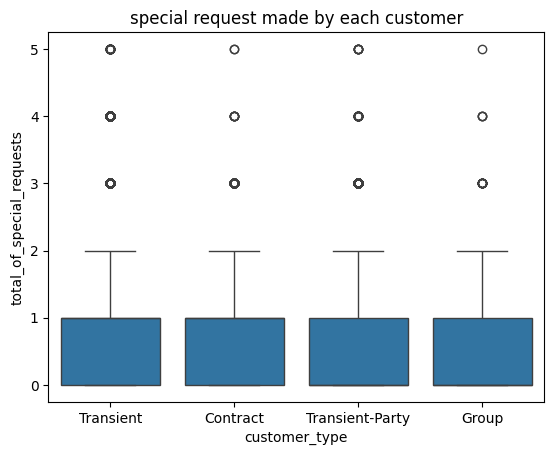

In [27]:
sns.boxplot(df, x='customer_type', y='total_of_special_requests')
plt.title('special request made by each customer')
plt.show()

irrespective of the customer type majority of the customers 0 or 1 special request, very few customers will have a 2 or more special request, any customer who are having request beyond 2 is very rare considerig it as an outlier

13. Compare the distribution of adr (Average Daily Rate) by customer_type for each hotel type

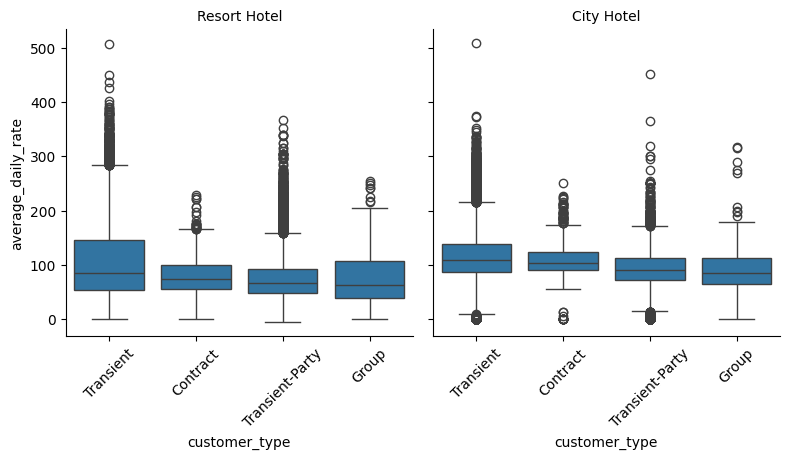

In [28]:
df_viz = df[df['average_daily_rate'] < 1000]  # cap extreme values

g = sns.FacetGrid(df_viz, col="hotel", height=4, aspect=1)
g.map(sns.boxplot, "customer_type", "average_daily_rate", order=df['customer_type'].unique())
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
plt.show()

in resort hotel transient cust has the highest ADR range where most of them pay close to the range (70-140) and a very few cust among them pay higher & lower to this range upto 290, any payment beyond 290 is a rare case thus considered an outlier

transient-party pays the lowest amount in resort hotel where most of them pay close to (60-95) a few of them pays higher & lower to this range which goes upto 170, abything beyond that price is a rare case making it an outlier

the same trend in city hotels, regarding transient type cust, most of them pay in a range of (90-140) and a few pays above and below this range here we have outlier due to extrem price and no price

group type of cust has the lowest ADR in city hotels mostly in the range of (85-110) a few pays above and below this range but the rare case here is the extrme pay which often act as outlier

OVERALL CONCLUSION

booking is more in city hotel compared to resort hotels, that too the customers prefer the no deposit policy 

the hotels major custoers are individuals or small groups

the ADR of both hotels rise seasonally and peaks during the august, and fall during the winter season

similarly the lead time is also affected seasonally, it peaks during july, and is the lowest at the time of winter season

the risk of booking cancellation is high if the lead time is high or this cancellation chance decrease if there is any special requests made 

sepcial request by guest is either 0 or 1 and avg count is almost same, this doesnt relates to the commitment of the customer to the hotel

the ADR is usually below the 700 mark irrespective of the lead time and doesnt have any direct relation to lead time

the avg of ADR is higher for no deposit type booking showing the price increase due to risk of cancellation and property damage